In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'

In [2]:
train1 = pd.read_csv('../data/train1_nofilter.csv',index_col=0)

### 엔진별 RUL 분포 확인

최대값 : 362   
최소값 : 128   
평균 : 206   
중앙값 : 199

count    100.0
mean     206.3
std       46.3
min      128.0
25%      177.0
50%      199.0
75%      229.2
max      362.0
Name: cycle, dtype: float64


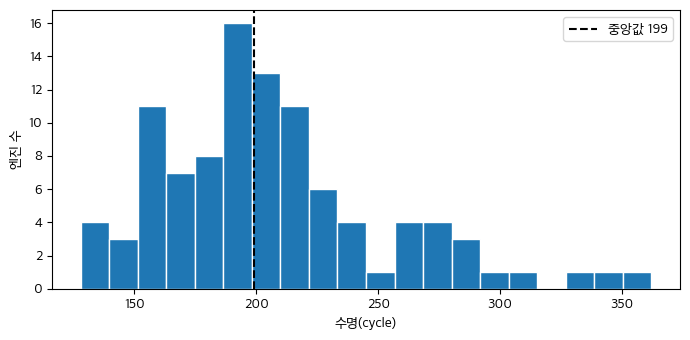

In [ ]:
life = train1.groupby("engine_id")["cycle"].max() #RUL
print(life.describe().round(1))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(life, bins=20, edgecolor="white")
ax.axvline(life.median(), ls="--", c="k", label=f"중앙값 {life.median():.0f}")
ax.set_xlabel("수명(cycle)"); ax.set_ylabel("엔진 수"); ax.legend()
plt.tight_layout(); plt.show()

### 열화 신호는 3차다항식보다는 지수함수에 가깝다. 
잔차를 구할 떄 3차 다항식을 뺴서 계산했는데, 틀린 추세선을 뺐을 때 오차는 커진다. 3차 다항식을 뺐을 떄 이미 잔차는 가우시안 분포이므로 지수 함수를 적용했을 때는 마찬가지로 가우시안 분포를 띌것이다.

#### 지수함수, 3차 다항식, 5차 다항식을 열화 신호에 피팅해서 비교한다.

In [8]:
sens = ['s2', 's3', 's4', 's7', 's8',
       's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']

In [51]:
from scipy.stats import skew, kurtosis
from scipy.optimize import curve_fit

def fit_ref(t, y, kind):
    if kind.startswith("poly"):
        return np.polyval(np.polyfit(t, y, int(kind[-1])), t)
    tt = t - t.max()                      # 고장 시점을 0으로 → k = 고장 시점의 변화량이라 피팅이 안정적
    c0 = np.median(y[:30]); k0 = np.mean(y[-10:]) - c0
    f = lambda t, c, k, r: c + k*np.exp(r*t)
    p, _ = curve_fit(f, tt, y, p0=[c0, k0, 0.03],
                     bounds=([-np.inf, -np.inf, 1e-4], [np.inf, np.inf, 0.5]), maxfev=5000)
    return f(tt, *p)


def compare_refs(df, sensors, kinds=("poly3", "poly5", "exp"), tail=50): # 지수함수 판단
    rows = []
    for s in sensors:
        for eid, g in df.groupby("engine_id"):
            t, y = g["cycle"].values.astype(float), g[s].values
            for kind in kinds:
                try:
                    res = y - fit_ref(t, y, kind)
                    sigma = res[:-tail].std()
                    rows.append({"sensor": s, "kind": kind,
                                 "tail_ratio": np.sqrt(np.mean(res[-tail:]**2)) / sigma,  # 1에 가까울수록 말기를 잘 따라감
                                 "fail": 0})
                except RuntimeError:
                    rows.append({"sensor": s, "kind": kind, "tail_ratio": np.nan, "fail": 1})
    out = pd.DataFrame(rows)
    return out.groupby(["sensor", "kind"]).agg(tail_ratio=("tail_ratio", "median"),
                                               fail=("fail", "sum")).unstack("kind").round(2)

print(compare_refs(train1, sens))

       tail_ratio             fail            
kind          exp poly3 poly5  exp poly3 poly5
sensor                                        
s11          1.00  1.01  1.00    0     0     0
s12          0.99  1.00  1.00    0     0     0
s13          1.01  1.02  1.01    0     0     0
s14          0.98  1.03  0.98    0     0     0
s15          0.96  0.97  0.96    0     0     0
s17          1.02  1.01  1.01    0     0     0
s2           0.99  0.99  0.99    0     0     0
s20          0.97  0.97  0.97    0     0     0
s21          0.98  0.99  0.98    0     0     0
s3           0.97  0.98  0.97    0     0     0
s4           0.99  1.01  0.99    0     0     0
s7           0.97  0.98  0.97    0     0     0
s8           1.00  1.01  1.01    0     0     0
s9           0.99  1.04  0.99    0     0     0


3차, 5차, 지수 모두 말기 잔차가 노이즈 수준(0.92~1.04)이었다. 잔차 분석 결론은 기준선 선택과 무관하다. 기본 기준선은 물리적 근거가 있고 파라미터가 적은 지수함수가 가장 적합하다.

In [10]:



def residual_stats(df, sensors, kinds=("poly3", "poly5", "exp"), late_frac=0.2):
    rows = []
    for s in sensors:
        for kind in kinds:
            early, late, n_fail = [], [], 0
            for eid, g in df.groupby("engine_id"):
                t, y = g["cycle"].values.astype(float), g[s].values
                try:
                    res = y - fit_ref(t, y, kind)
                except RuntimeError:
                    n_fail += 1; continue
                cut = int(len(res) * (1 - late_frac))
                res = res / res[:cut].std()        # 초중반 노이즈 크기로 엔진별 표준화
                early.append(res[:cut]); late.append(res[cut:])
            for part, arr in [("early", np.concatenate(early)), ("late", np.concatenate(late))]:
                rows.append({"sensor": s, "kind": kind, "part": part,
                             "skew": skew(arr), "ex_kurt": kurtosis(arr),   # 초과첨도(정규=0)
                             "std": arr.std(),                              # late가 1보다 크면 말기 산포 증가
                             "over3σ_%": (np.abs(arr) > 3).mean() * 100,    # 정규 이론값 0.27
                             "fail": n_fail})
    return (pd.DataFrame(rows)
              .pivot_table(index=["sensor", "part"], columns="kind",
                           values=["ex_kurt", "over3σ_%", "std", "fail"])
              .round(2))

stats = residual_stats(train1, sens)
print(stats["ex_kurt"]); print(stats["over3σ_%"]); print(stats["std"])

kind           exp  poly3  poly5
sensor part                     
s11    early -0.04  -0.04  -0.05
       late   0.11   0.15   0.11
s12    early -0.02  -0.03  -0.02
       late  -0.08  -0.09  -0.06
s13    early -0.02  -0.03  -0.02
       late   2.85  11.18   6.10
s14    early -0.06  -0.09  -0.06
       late  -0.03   0.27  -0.04
s15    early  0.01   0.00   0.01
       late   0.09   0.07   0.08
s17    early -0.02  -0.02  -0.02
       late   0.09   0.12   0.12
s2     early -0.00  -0.00  -0.00
       late   0.02   0.03   0.03
s20    early -0.04  -0.05  -0.04
       late  -0.04  -0.04  -0.05
s21    early -0.11  -0.12  -0.11
       late  -0.01  -0.01   0.01
s3     early -0.04  -0.04  -0.04
       late   0.07   0.09   0.04
s4     early -0.02  -0.01   0.01
       late   0.04   0.06   0.00
s7     early  0.02   0.02   0.04
       late   0.07   0.09   0.06
s8     early -0.03  -0.02  -0.02
       late   2.80  14.95   7.84
s9     early -0.04  -0.04  -0.03
       late   0.14   0.40   0.14
kind      

## 지수곡선 ŷ = c + k·exp(r·t)

|파라미터| 의미|
|---|---|
|c|	건강할 때 기준값 (초기 수준)|
|k|고장 시점까지 변한 총량 (부호 = 방향)|
|c + k|	고장 시점의 값|
|r|휘는 속도 (클수록 늦게, 급하게 꺾임)|
|σ|	노이즈 크기|


### 엔진별로, 센서별로 다른 곡선들을 최소제곱법을 통해 찾았으니, 이제 이 곡선들을 통해 알 수 있는 공통적인 특징이 뭘까?
|공통특징|계산|어디에쓰나|
|------|------|-------|
|방향이 엔진 간에 같은가|k 부호의 일관성|센서 선별. ②의 스피어만 결과와 교차 검증|
|노이즈 대비 변화가 큰가| 절대값(k) / σ (고장 시점의 신호 대 잡음비) |센서 우선순위, 대시보드에 띄울 센서|
|고장 시점의 값이 엔진 간에 비슷한가|c+k의 퍼짐 vs c의 퍼짐|알람 임계값(D09). 고장 값이 모여 있으면 "이 값을 넘으면 위험"이라는 공통 임계값이 성립|
|열화가 언제 시작되나 (무릎)|곡선이 기준값에서 σ만큼 벗어나는 RUL = ln(절대값(k)/σ) / r|	RUL 상한(D06). 이 값의 분포가 근거
|빨리 꺾이는 엔진이 일찍 죽나|r과 수명의 상관|엔진 간 차이를 설명할 수 있는지|



In [ ]:
from scipy.optimize import curve_fit

def fit_exp_params(t, y):
    tt = t - t.max()                                   # 고장 시점 = 0
    f = lambda t, c, k, r: c + k*np.exp(r*t)
    c0 = np.median(y[:30]); k0 = np.mean(y[-10:]) - c0
    p, _ = curve_fit(f, tt, y, p0=[c0, k0, 0.03],
                     bounds=([-np.inf, -np.inf, 1e-4], [np.inf, np.inf, 0.5]), maxfev=5000)
    return p, np.std(y - f(tt, *p))

rows = []
for s in sens:
    for eid, g in train1.groupby("engine_id"):
        t, y = g["cycle"].values.astype(float), g[s].values
        (c, k, r), sigma = fit_exp_params(t, y)
        snr = abs(k) / sigma
        rows.append({"sensor": s, "engine": eid, "life": t.max(),
                     "c": c, "k": k, "r": r, "sigma": sigma, "end": c + k, "snr": snr,
                     "knee_1s": np.log(snr) / r if snr > 1 else np.nan,       # 1σ 벗어나는 RUL
                     "knee_2s": np.log(snr / 2) / r if snr > 2 else np.nan})  # 2σ 벗어나는 RUL
P = pd.DataFrame(rows)

def common_traits(d):
    sgn = np.sign(d.k.median())
    scale = d.k.abs().median()                         # 전형적인 변화량으로 정규화 → 센서 간 비교 가능
    return pd.Series({
        "방향일관성":    (np.sign(d.k) == sgn).mean(),
        "snr_중앙":      d.snr.median(),
        "시작값_퍼짐":   d.c.std() / scale,            # 크면 엔진별 초기값 보정 필요
        "고장값_퍼짐":   d.end.std() / scale,          # 작으면 공통 알람 임계값 가능
        "무릎1σ_중앙":   d.knee_1s.median(),
        "무릎1σ_IQR":    d.knee_1s.quantile(.75) - d.knee_1s.quantile(.25),
        "무릎2σ_중앙":   d.knee_2s.median(),
        "r_수명_상관":   d[["r", "life"]].corr(method="spearman").iloc[0, 1],
    })

traits = P.groupby("sensor").apply(common_traits).round(2).sort_values("snr_중앙", ascending=False)
print(traits)

        방향일관성  snr_중앙  시작값_퍼짐  고장값_퍼짐  무릎1σ_중앙  무릎1σ_IQR  무릎2σ_중앙  r_수명_상관
sensor                                                                    
s14      0.59    8.81    0.39    1.96   101.59     62.31    74.50    -0.62
s11      1.00    8.09    0.18    0.06   106.08     44.97    71.48    -0.79
s9       0.71    7.43    1.31    1.82   107.99     92.49    82.51    -0.47
s12      1.00    7.32    0.19    0.12   101.10     42.62    66.70    -0.74
s4       1.00    6.98    0.16    0.05    98.52     34.09    61.91    -0.71
s7       1.00    6.40    0.19    0.11    99.67     46.41    60.94    -0.73
s8       1.00    6.40    0.24    0.33    96.08     56.01    60.85    -0.51
s13      1.00    6.35    0.25    0.36    96.66     60.09    60.38    -0.57
s15      1.00    5.47    0.17    0.05    85.48     37.16    50.26    -0.73
s20      1.00    5.23    0.16    0.07    85.03     38.66    47.64    -0.67
s21      1.00    5.23    0.17    0.06    84.55     37.04    48.28    -0.66
s2       1.00    4.57    

/var/folders/w5/9zknfqrs3dn6cmzpl11fhmmw0000gn/T/ipykernel_14445/3983778223.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  traits = P.groupby("sensor").apply(common_traits).round(2).sort_values("snr_중앙", ascending=False)


방향 일관성 = s14, s9 이외엔 일정 => 해당 센서는 제외 후보
고장값_퍼짐 = 매우일정(s11,s4,s15,s20,s21,s2), 적당히 일정(s12,s7s17,s3), 

In [42]:
# 무릎과 수명의 관계
knee_life = (P[P.sensor.isin(sens)].groupby("sensor")
               .apply(lambda d: d[["knee_1s", "life"]].corr(method="spearman").iloc[0, 1])
               .round(2))
print(knee_life)

sensor
s11    0.75
s12    0.68
s13    0.44
s14    0.49
s15    0.74
s17    0.70
s2     0.60
s20    0.68
s21    0.65
s3     0.69
s4     0.73
s7     0.69
s8     0.38
s9     0.50
dtype: float64


/var/folders/w5/9zknfqrs3dn6cmzpl11fhmmw0000gn/T/ipykernel_14445/1510529366.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d[["knee_1s", "life"]].corr(method="spearman").iloc[0, 1])


In [48]:
sens12 = ["s2","s3","s4","s7","s8","s11","s12","s13","s15","s17","s20","s21"]
sign = P.groupby("sensor")["k"].median().apply(np.sign)        # 센서별 열화 방향
sig  = P.set_index(["engine", "sensor"])["sigma"]               # 엔진·센서별 노이즈 크기

rows, HI_curves = [], {}
for eid, g in train1.groupby("engine_id"):
    t = g["cycle"].values.astype(float)
    z = np.mean([sign[s] * (g[s].values - g[s].values[:30].mean()) / sig[(eid, s)]
                 for s in sens12], axis=0)                      # 초기 30사이클 대비 벗어난 정도(σ 단위)의 평균
    HI_curves[eid] = (t.max() - t, z)
    (c, k, r), sz = fit_exp_params(t, z)
    snr = abs(k) / sz
    rows.append({"engine": eid, "life": t.max(), "snr": snr,
                 "knee_1s": np.log(snr) / r if snr > 1 else np.nan,
                 "knee_2s": np.log(snr / 2) / r if snr > 2 else np.nan})
HI = pd.DataFrame(rows)
print(HI[["snr", "knee_1s", "knee_2s"]].describe().round(1))
print("결합 무릎-수명 상관:", round(HI[["knee_1s", "life"]].corr(method="spearman").iloc[0, 1], 2))

         snr  knee_1s  knee_2s
count  100.0    100.0    100.0
mean    19.1    155.9    119.2
std      3.7     46.3     36.4
min     11.5     79.7     59.0
25%     16.1    119.2     91.4
50%     18.7    149.8    115.1
75%     21.9    177.7    138.2
max     25.8    309.6    238.3
결합 무릎-수명 상관: 0.74


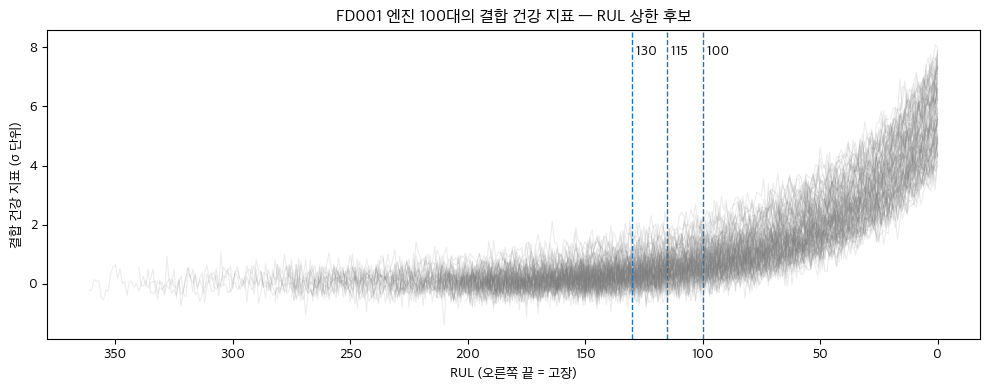

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
for eid, (rul, z) in HI_curves.items():
    ax.plot(rul, z, color="gray", alpha=.15, lw=.8)
for cap in [100, 115, 130]: 
    ax.axvline(cap, ls="--", lw=1); ax.text(cap, ax.get_ylim()[1]*.9, f" {cap}")
ax.invert_xaxis(); ax.set_xlabel("RUL (오른쪽 끝 = 고장)"); ax.set_ylabel("결합 건강 지표 (σ 단위)")
ax.set_title("FD001 엔진 100대의 결합 건강 지표 — RUL 상한 후보")
plt.tight_layout(); plt.show()

In [50]:
corr_list = []
for eid, g in train1.groupby("engine_id"):
    t = g["cycle"].values.astype(float)
    res = pd.DataFrame({s: g[s].values - fit_ref(t, g[s].values, "exp") for s in sens12})
    corr_list.append(res.corr().values)
mean_corr = pd.DataFrame(np.mean(corr_list, axis=0), index=sens12, columns=sens12).round(2)
off = mean_corr.values[~np.eye(len(sens12), dtype=bool)]
print(mean_corr)
print("대각선 제외 평균 상관:", off.mean().round(3), " 절댓값 최대:", np.abs(off).max().round(2))

       s2    s3    s4    s7    s8   s11   s12   s13   s15   s17   s20   s21
s2   1.00  0.00  0.01  0.01  0.01  0.01 -0.01  0.01  0.00  0.01  0.00 -0.01
s3   0.00  1.00  0.02 -0.01  0.01  0.01 -0.02  0.01  0.00  0.01  0.00 -0.02
s4   0.01  0.02  1.00 -0.01  0.02  0.02 -0.02  0.01  0.01  0.01 -0.02 -0.00
s7   0.01 -0.01 -0.01  1.00 -0.03 -0.01  0.01 -0.02 -0.01 -0.02  0.01  0.01
s8   0.01  0.01  0.02 -0.03  1.00  0.01 -0.00  0.04  0.02  0.01 -0.01 -0.01
s11  0.01  0.01  0.02 -0.01  0.01  1.00 -0.03  0.01 -0.00 -0.00 -0.02 -0.02
s12 -0.01 -0.02 -0.02  0.01 -0.00 -0.03  1.00 -0.01 -0.00  0.00  0.00  0.02
s13  0.01  0.01  0.01 -0.02  0.04  0.01 -0.01  1.00  0.01  0.01 -0.01 -0.02
s15  0.00  0.00  0.01 -0.01  0.02 -0.00 -0.00  0.01  1.00  0.02 -0.02 -0.00
s17  0.01  0.01  0.01 -0.02  0.01 -0.00  0.00  0.01  0.02  1.00  0.00 -0.02
s20  0.00  0.00 -0.02  0.01 -0.01 -0.02  0.00 -0.01 -0.02  0.00  1.00  0.01
s21 -0.01 -0.02 -0.00  0.01 -0.01 -0.02  0.02 -0.02 -0.00 -0.02  0.01  1.00
대각선 제외 평균 상관

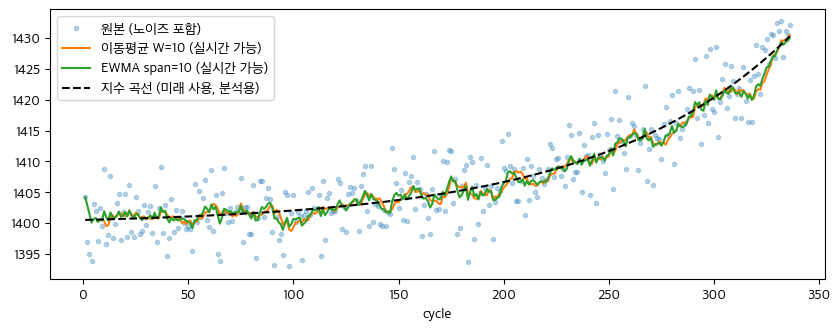

In [26]:
g = train1[train1.engine_id == 96]
t, y = g["cycle"].values.astype(float), g["s4"].values
plt.figure(figsize=(10, 3.5))
plt.plot(t, y, ".", alpha=.3, label="원본 (노이즈 포함)")
plt.plot(t, pd.Series(y).rolling(10).mean(), label="이동평균 W=10 (실시간 가능)")
plt.plot(t, pd.Series(y).ewm(span=10, adjust=False).mean(), label="EWMA span=10 (실시간 가능)")
plt.plot(t, fit_ref(t, y, "exp"), "k--", label="지수 곡선 (미래 사용, 분석용)")
plt.legend(); plt.xlabel("cycle"); plt.show()

### 노이즈가 문제인지 확인헤보자

In [36]:
print(train1[["op1", "op2", "op3"]].describe().round(4))

              op1         op2      op3
count  20631.0000  20631.0000  20631.0
mean      -0.0000      0.0000    100.0
std        0.0022      0.0003      0.0
min       -0.0087     -0.0006    100.0
25%       -0.0015     -0.0002    100.0
50%        0.0000      0.0000    100.0
75%        0.0015      0.0003    100.0
max        0.0087      0.0006    100.0


### 칼만필터사용

In [27]:
def kalman_llt(y, r, q):
    """국소 선형 추세 칼만 필터 (인과적: 과거·현재 값만 사용)
    상태 x = [수준, 기울기], r: 측정 노이즈 분산, q: 기울기 변화 허용 정도"""
    F = np.array([[1., 1.], [0., 1.]])            # 다음 수준 = 수준 + 기울기, 기울기는 유지
    H = np.array([[1., 0.]])                      # 측정되는 건 수준뿐
    Q = q * np.array([[1/3, 1/2], [1/2, 1.]])     # 기울기가 조금씩 변할 수 있게 허용
    x = np.array([y[0], 0.])                      # 초기: 첫 값, 기울기 0
    P = np.diag([r, r])                           # 초기 불확실성
    level, slope, var = [], [], []
    for z in y:
        x = F @ x;  P = F @ P @ F.T + Q           # ① 예측
        S = H @ P @ H.T + r
        K = (P @ H.T) / S                         # 칼만 이득
        x = x + (K * (z - H @ x)).ravel()         # ② 보정
        P = (np.eye(2) - K @ H) @ P
        level.append(x[0]); slope.append(x[1]); var.append(P[0, 0])
    return np.array(level), np.array(slope), np.array(var)

In [28]:
sens12 = ["s2","s3","s4","s7","s8","s11","s12","s13","s15","s17","s20","s21"]
R = P.groupby("sensor")["sigma"].median() ** 2    # 측정 노이즈 분산: train의 지수 곡선 잔차로 추정

def smooth_methods(y, r):
    out = {}
    for W in [5, 10, 20]:
        out[f"MA{W}"]   = pd.Series(y).rolling(W, min_periods=W).mean().values
        out[f"EWMA{W}"] = pd.Series(y).ewm(span=W, adjust=False).mean().values
    for qr in [1e-6, 1e-5, 1e-4, 1e-3]:           # q를 r 대비 비율로 → 센서끼리 같은 격자
        out[f"KF_q{qr:g}"] = kalman_llt(y, r, qr * r)[0]
    return out

rows = []
for s in sens12:
    for eid, g in raw.groupby("engine_id"):
        t, y = g["cycle"].values.astype(float), g[s].values
        ref = fit_ref(t, y, "exp"); sigma = np.std(y - ref)   # 오프라인 기준선 (채점용)
        for name, est in smooth_methods(y, R[s]).items():
            err = est - ref
            rows.append({"sensor": s, "method": name,
                         "noise_ratio": np.nanstd(err[30:-20]) / sigma,              # 초기 30사이클(워밍업) 제외
                         "eol_rmse":    np.sqrt(np.nanmean(err[-20:]**2)) / sigma})  # 말기: 노이즈 + 지연
cmp = (pd.DataFrame(rows).groupby("method")[["noise_ratio", "eol_rmse"]]
         .median().sort_values("eol_rmse").round(3))
print(cmp)

            noise_ratio  eol_rmse
method                           
KF_q0.0001        0.298     0.268
KF_q0.001         0.399     0.344
KF_q1e-05         0.232     0.387
MA5               0.436     0.427
EWMA5             0.437     0.429
EWMA10            0.308     0.458
MA10              0.308     0.473
EWMA20            0.247     0.757
KF_q1e-06         0.240     0.803
MA20              0.252     0.804


In [33]:
g = train1[train1.engine_id == 2]; t, y = g["cycle"].values.astype(float), g["s11"].values
lv, sl, vr = kalman_llt(y, R["s11"], 1e-4 * R["s11"])
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(t, y, ".", alpha=.3, label="원본")
ax[0].plot(t, pd.Series(y).ewm(span=10, adjust=False).mean(), label="EWMA10")
ax[0].plot(t, lv, label="칼만 수준")
ax[0].fill_between(t, lv - 2*np.sqrt(vr), lv + 2*np.sqrt(vr), alpha=.2, label="칼만 ±2σ")
ax[0].plot(t, fit_ref(t, y, "exp"), "k--", label="지수 곡선(분석용)"); ax[0].legend()
ax[1].plot(t, sl); ax[1].set_ylabel("칼만 기울기 (열화 속도)"); ax[1].set_xlabel("cycle")
plt.tight_layout(); plt.show()

ValueError: too many values to unpack (expected 3)

In [30]:
def kalman_llt(y, r, q):
    F = np.array([[1., 1.], [0., 1.]]); H = np.array([[1., 0.]])
    Q = q * np.array([[1/3, 1/2], [1/2, 1.]])
    x = np.array([y[0], 0.]); P = np.diag([r, r])
    level, slope, var, nis = [], [], [], []
    for z in y:
        x = F @ x;  P = F @ P @ F.T + Q
        S = (H @ P @ H.T).item() + r
        nu = z - (H @ x).item()                    # 혁신값: 측정 − 예측
        K = (P @ H.T) / S
        x = x + K.ravel() * nu
        P = (np.eye(2) - K @ H) @ P
        level.append(x[0]); slope.append(x[1]); var.append(P[0, 0])
        nis.append(nu / np.sqrt(S))                # 정규화 혁신 (맞으면 ~ N(0,1))
    return np.array(level), np.array(slope), np.array(var), np.array(nis)

rows = []
for s in sens12:
    for qr in [1e-6, 1e-5, 1e-4, 1e-3]:
        for r_mult in [0.5, 1, 2]:                 # r 과대추정 여부도 같이 확인
            for eid, g in raw.groupby("engine_id"):
                y = g[s].values
                e = kalman_llt(y, r_mult * R[s], qr * R[s])[3][30:]   # 초기 30사이클 제외
                n = len(e); cut = int(n * 0.8)
                rows.append({"sensor": s, "q_ratio": qr, "r_mult": r_mult,
                             "NIS_전체": np.mean(e**2),
                             "NIS_말기": np.mean(e[cut:]**2),
                             "자기상관": np.corrcoef(e[:-1], e[1:])[0, 1]})
nis_tbl = (pd.DataFrame(rows).groupby(["q_ratio", "r_mult"])
             [["NIS_전체", "NIS_말기", "자기상관"]].median().round(2))
print(nis_tbl)

                 NIS_전체  NIS_말기  자기상관
q_ratio  r_mult                      
0.000001 0.5       2.19    2.71  0.04
         1.0       1.14    1.53  0.06
         2.0       0.60    0.89  0.09
0.000010 0.5       2.03    2.11 -0.01
         1.0       1.03    1.11  0.00
         2.0       0.53    0.59  0.01
0.000100 0.5       1.95    1.93 -0.04
         1.0       0.98    0.98 -0.03
         2.0       0.50    0.50 -0.02
0.001000 0.5       1.88    1.83 -0.08
         1.0       0.95    0.93 -0.06
         2.0       0.48    0.47 -0.05
